# 23. Switching Factor-PVAR Prototype
This notebook is a light-weight analysis shell for the prototype model.


In [4]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.pyplot as plt
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import config

OUT = Path(PROJECT_ROOT/config.OUTPUT_DIR)
art = np.load(OUT / "unit_switching_pvar_k3_artifacts.npz", allow_pickle=True)

print(art.files)


['units', 'tasks', 'feature_names', 'x_mean', 'x_std', 'y_true_oof', 'y_pred_oof', 'regime_prob_pred', 'regime_prob_filt', 'W', 'A', 'B', 'c', 'sigma2', 'Pi', 'pi0', 'loss_history', 'train_end']


In [2]:
y_true = art["y_true_oof"]              # (n_oof_rows, 7)
y_pred = art["y_pred_oof"]              # (n_oof_rows, 7)

gamma = art["regime_prob_filt"]         # likely (N, T_oof, K)
A = art["A"]                            # (K, 7, 7)
B = art["B"]                            # (K, p, 7)
Pi = art["Pi"]                          # (K, K)
feature_names = art["feature_names"]

print("y_true:", y_true.shape)
print("y_pred:", y_pred.shape)
print("gamma:", gamma.shape)
print("A:", A.shape)
print("B:", B.shape)
print("Pi:", Pi.shape)
print("n feature_names:", len(feature_names))

y_true: (531822, 7)
y_pred: (531822, 7)
gamma: (302, 1761, 3)
A: (3, 7, 7)
B: (3, 65, 7)
Pi: (3, 3)
n feature_names: 65


In [3]:
# dominant regime at each unit-time OOS observation
dom_regime = np.argmax(gamma, axis=2)   # shape: (N, T_oof)

shares = np.bincount(dom_regime.reshape(-1), minlength=gamma.shape[2])
shares = shares / shares.sum()

share_df = pd.DataFrame({
    "regime": [f"Regime {k+1}" for k in range(gamma.shape[2])],
    "share": shares
})
display(share_df)

,regime,share
0,Regime 1,0.057243
1,Regime 2,0.648311
2,Regime 3,0.294446


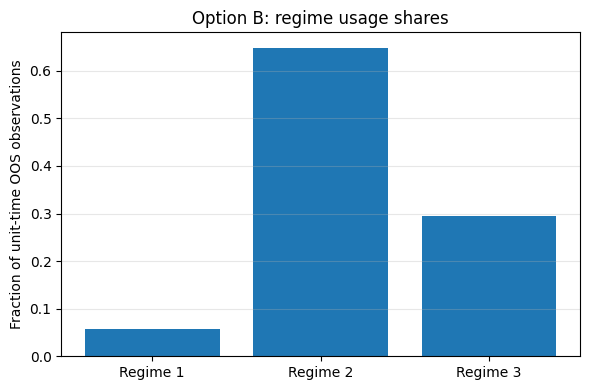

In [4]:
plt.figure(figsize=(6,4))
plt.bar(share_df["regime"], share_df["share"])
plt.title("Option B: regime usage shares")
plt.ylabel("Fraction of unit-time OOS observations")
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

In [6]:
mean_gamma = gamma.mean(axis=(0,1))
mean_gamma_df = pd.DataFrame({
    "regime": [f"Regime {k+1}" for k in range(gamma.shape[2])],
    "mean_probability": mean_gamma
})
display(mean_gamma_df)

,regime,mean_probability
0,Regime 1,0.057277
1,Regime 2,0.650162
2,Regime 3,0.292561


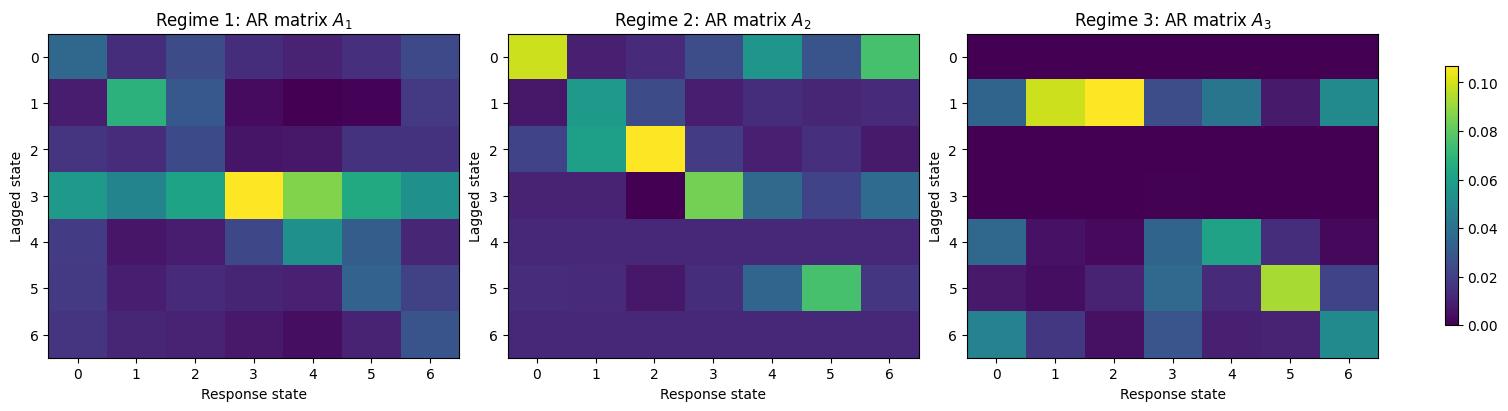

In [7]:
K = A.shape[0]
d = A.shape[1]

fig, axes = plt.subplots(1, K, figsize=(5*K, 4), constrained_layout=True)

if K == 1:
    axes = [axes]

for k in range(K):
    im = axes[k].imshow(A[k], aspect="auto")
    axes[k].set_title(f"Regime {k+1}: AR matrix $A_{k+1}$")
    axes[k].set_xlabel("Response state")
    axes[k].set_ylabel("Lagged state")
    axes[k].set_xticks(range(d))
    axes[k].set_yticks(range(d))

fig.colorbar(im, ax=axes, shrink=0.8)
plt.show()

In [8]:
rows = []
for k in range(K):
    Ak = A[k]
    diag_mean = np.mean(np.diag(Ak))
    offdiag = Ak - np.diag(np.diag(Ak))
    offdiag_mean = np.mean(np.abs(offdiag))
    rows.append({
        "regime": f"Regime {k+1}",
        "mean_diag_A": diag_mean,
        "mean_abs_offdiag_A": offdiag_mean
    })

A_summary = pd.DataFrame(rows)
display(A_summary)

,regime,mean_diag_A,mean_abs_offdiag_A
0,Regime 1,0.045979,0.012679
1,Regime 2,0.071604,0.009841
2,Regime 3,0.043541,0.011642


In [9]:
for k in range(K):
    importance = np.mean(np.abs(B[k]), axis=1)  # average across 7 response states
    df = pd.DataFrame({
        "covariate": feature_names,
        "importance": importance
    }).sort_values("importance", ascending=False)

    print(f"\nTop 15 covariates in Regime {k+1}")
    display(df.head(15))


Top 15 covariates in Regime 1


,covariate,importance
4,occupancy_roll_state_3,0.605392
5,occupancy_roll_state_4,0.541849
34,transition_roll_3_3,0.503159
42,transition_roll_4_4,0.426175
2,occupancy_roll_state_1,0.371456
6,occupancy_roll_state_5,0.324979
1,occupancy_roll_state_0,0.321026
7,occupancy_roll_state_6,0.292725
50,transition_roll_5_5,0.267279
10,transition_roll_0_0,0.264958



Top 15 covariates in Regime 2


,covariate,importance
3,occupancy_roll_state_2,0.608237
4,occupancy_roll_state_3,0.601747
1,occupancy_roll_state_0,0.592744
34,transition_roll_3_3,0.494357
6,occupancy_roll_state_5,0.481521
26,transition_roll_2_2,0.476630
10,transition_roll_0_0,0.454958
50,transition_roll_5_5,0.381666
2,occupancy_roll_state_1,0.225487
18,transition_roll_1_1,0.152266



Top 15 covariates in Regime 3


,covariate,importance
5,occupancy_roll_state_4,0.616169
2,occupancy_roll_state_1,0.535995
7,occupancy_roll_state_6,0.495655
42,transition_roll_4_4,0.485986
6,occupancy_roll_state_5,0.478315
50,transition_roll_5_5,0.365549
18,transition_roll_1_1,0.353689
58,transition_roll_6_6,0.335029
19,transition_roll_1_2,0.105550
52,transition_roll_6_0,0.100262


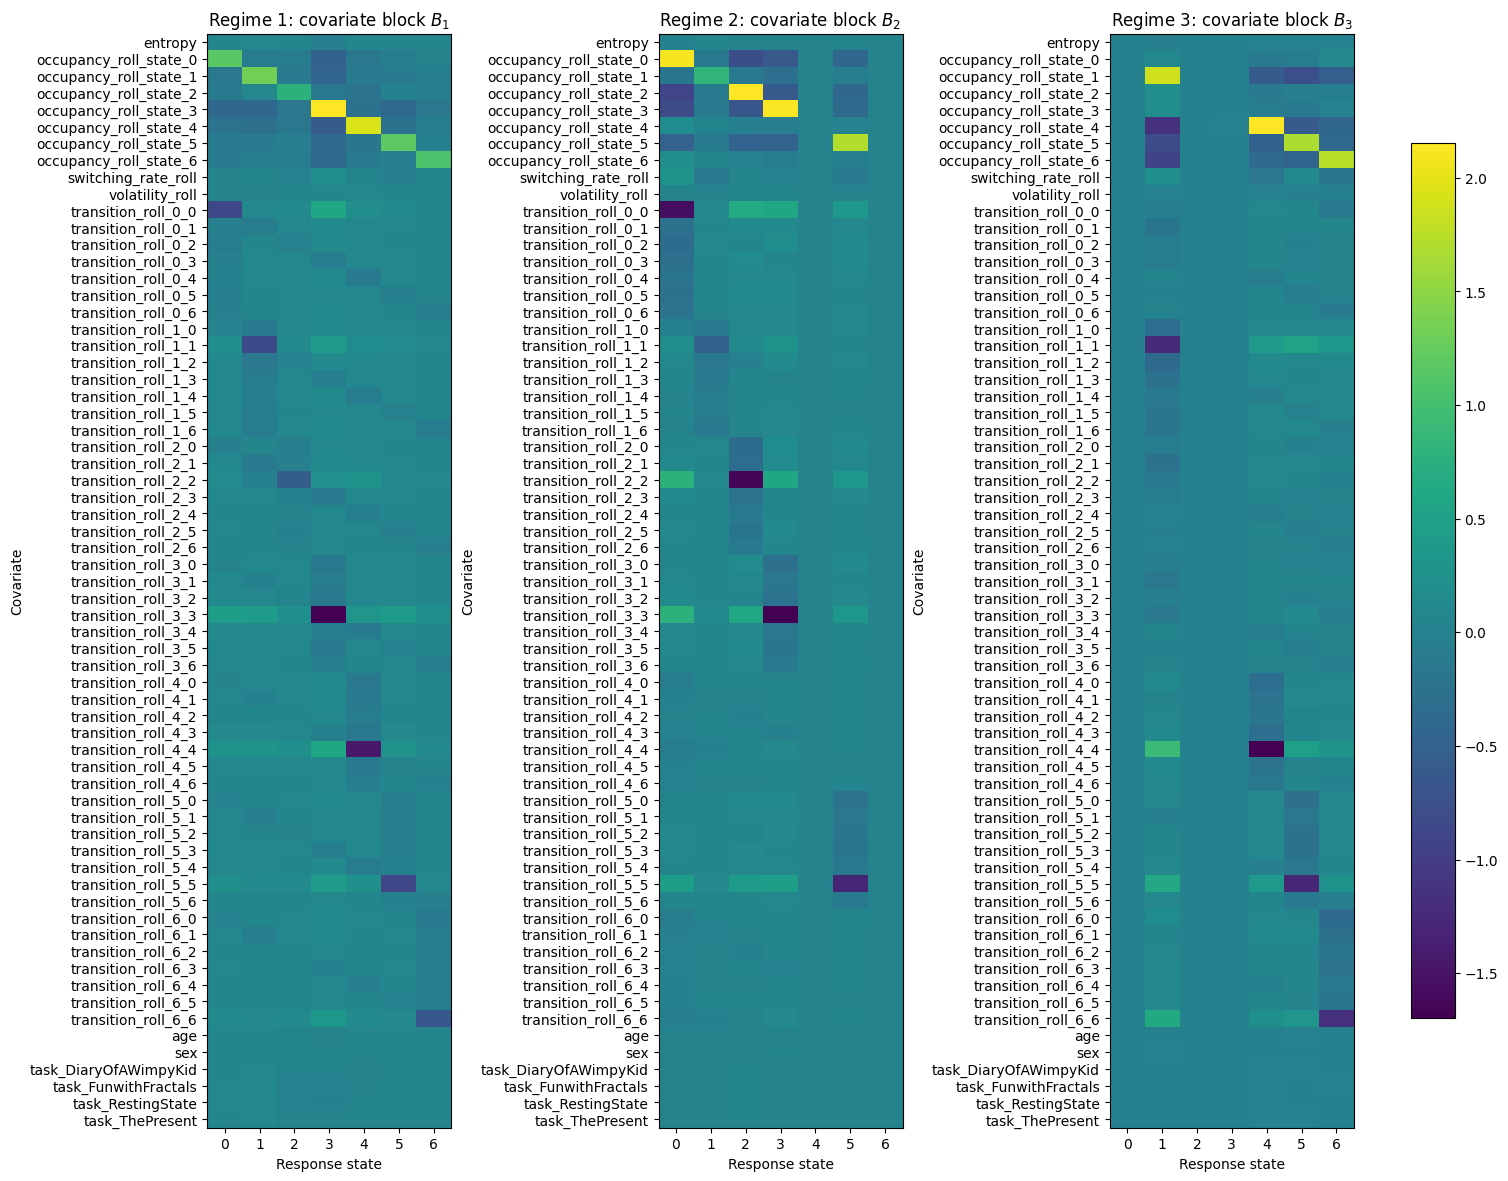

In [10]:
p = B.shape[1]

fig, axes = plt.subplots(1, K, figsize=(5*K, max(4, p*0.18)), constrained_layout=True)

if K == 1:
    axes = [axes]

for k in range(K):
    im = axes[k].imshow(B[k], aspect="auto")
    axes[k].set_title(f"Regime {k+1}: covariate block $B_{k+1}$")
    axes[k].set_xlabel("Response state")
    axes[k].set_ylabel("Covariate")
    axes[k].set_xticks(range(d))
    axes[k].set_yticks(range(p))
    axes[k].set_yticklabels(feature_names)

fig.colorbar(im, ax=axes, shrink=0.8)
plt.show()

In [11]:
rows = []
for k in range(K):
    rows.append({
        "regime": f"Regime {k+1}",
        "mean_abs_covariate_effect": np.mean(np.abs(B[k]))
    })

B_summary = pd.DataFrame(rows)
display(B_summary)

,regime,mean_abs_covariate_effect
0,Regime 1,0.109749
1,Regime 2,0.104957
2,Regime 3,0.095150


In [12]:
true_state = np.argmax(y_true, axis=1)
pred_state = np.argmax(y_pred, axis=1)

conf = pd.crosstab(
    pd.Series(true_state, name="true"),
    pd.Series(pred_state, name="pred")
)
display(conf)

pred,0,1,2,3,4,5,6
true,,,,,,,
0,129861,67,5110,1958,22,542,0
1,4274,66085,4882,1272,229,441,245
2,7361,96,97437,1457,26,585,0
3,4301,122,2014,71704,67,328,0
4,2,1789,1,406,33462,161,71
5,1586,2409,850,1056,78,54554,46
6,2,2168,0,303,75,105,32212


In [13]:
conf_row = conf.div(conf.sum(axis=1), axis=0)
display(conf_row)

pred,0,1,2,3,4,5,6
true,,,,,,,
0,0.944032,0.000487,0.037147,0.014234,0.000160,0.003940,0.000000
1,0.055200,0.853503,0.063052,0.016428,0.002958,0.005696,0.003164
2,0.068819,0.000898,0.910950,0.013622,0.000243,0.005469,0.000000
3,0.054765,0.001553,0.025644,0.913008,0.000853,0.004176,0.000000
4,0.000056,0.049844,0.000028,0.011312,0.932297,0.004486,0.001978
5,0.026181,0.039766,0.014031,0.017432,0.001288,0.900543,0.000759
6,0.000057,0.062183,0.000000,0.008691,0.002151,0.003012,0.923906


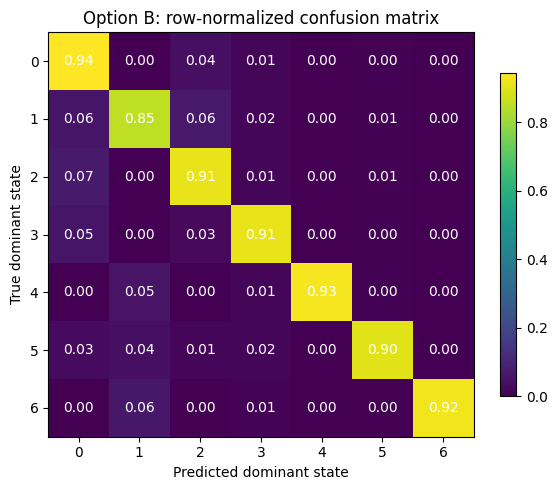

In [15]:
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(conf_row.values, aspect="auto")
ax.set_title("Option B: row-normalized confusion matrix")
ax.set_xlabel("Predicted dominant state")
ax.set_ylabel("True dominant state")
ax.set_xticks(range(conf_row.shape[1]))
ax.set_yticks(range(conf_row.shape[0]))
ax.set_xticklabels(conf_row.columns)
ax.set_yticklabels(conf_row.index)

for i in range(conf_row.shape[0]):
    for j in range(conf_row.shape[1]):
        ax.text(j, i, f"{conf_row.values[i,j]:.2f}", ha="center", va="center", color="white")

fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

In [16]:
state_recall = np.diag(conf.values) / conf.sum(axis=1).values
recall_df = pd.DataFrame({
    "state": conf.index,
    "recall": state_recall
})
display(recall_df)

,state,recall
0,0,0.944032
1,1,0.853503
2,2,0.910950
3,3,0.913008
4,4,0.932297
5,5,0.900543
6,6,0.923906


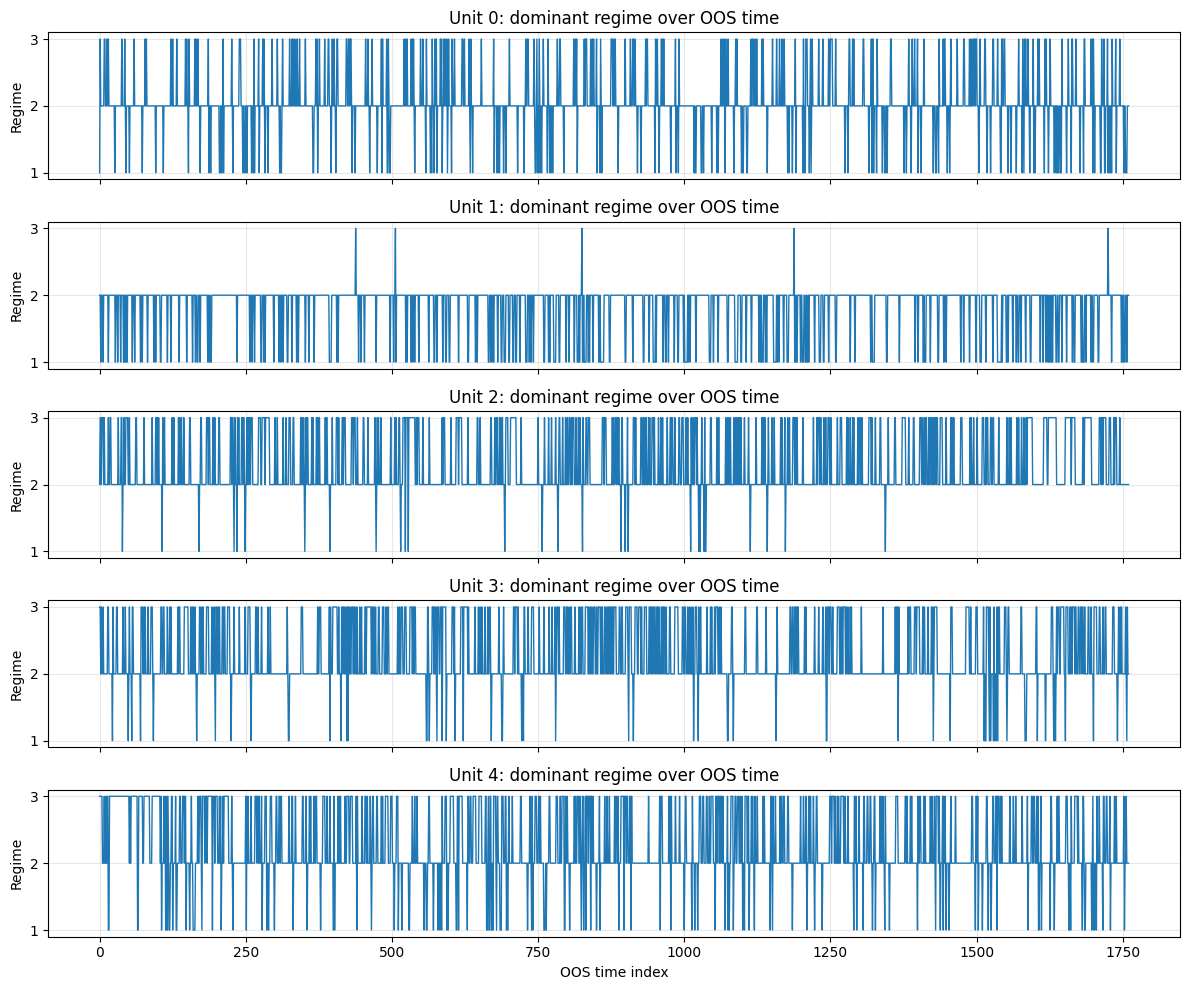

In [17]:
example_units = [0, 1, 2, 3, 4]

fig, axes = plt.subplots(len(example_units), 1, figsize=(12, 2*len(example_units)), sharex=True)

for ax, i in zip(axes, example_units):
    dom_i = np.argmax(gamma[i], axis=1)
    ax.plot(dom_i, lw=1)
    ax.set_title(f"Unit {i}: dominant regime over OOS time")
    ax.set_ylabel("Regime")
    ax.set_yticks(range(K))
    ax.set_yticklabels([f"{k+1}" for k in range(K)])
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("OOS time index")
plt.tight_layout()
plt.show()

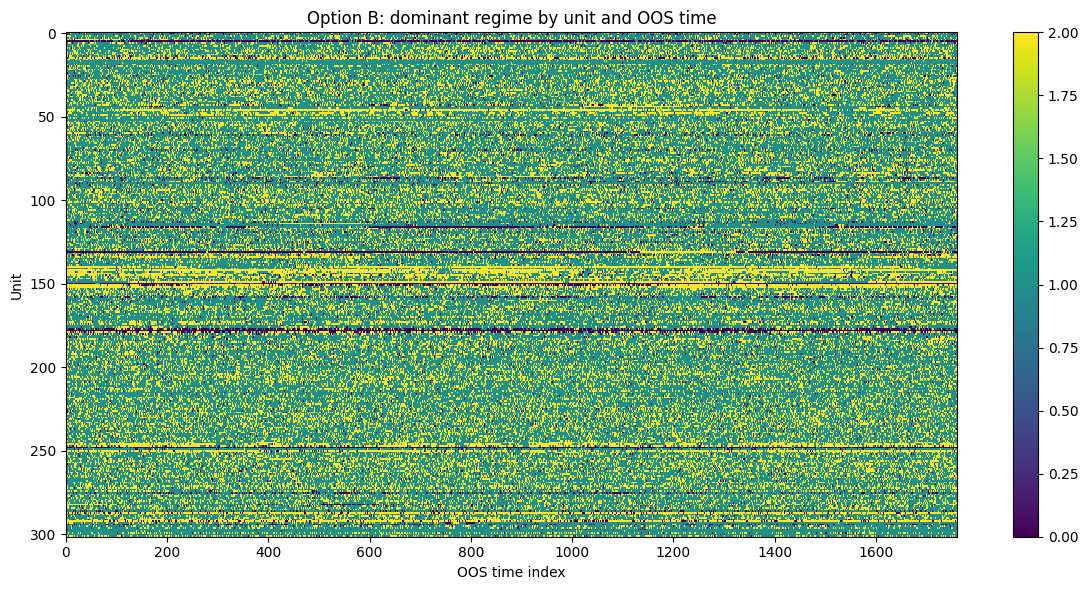

In [19]:
dom_all = np.argmax(gamma, axis=2)   # (N, T_oof)

plt.figure(figsize=(12,6))
plt.imshow(dom_all, aspect="auto", interpolation="nearest")
plt.title("Option B: dominant regime by unit and OOS time")
plt.xlabel("OOS time index")
plt.ylabel("Unit")
plt.colorbar()
plt.tight_layout()
plt.show()

In [8]:
gamma = art["regime_prob_filt"]   # (N, T, K)
gamma.shape
mean_gamma = gamma.mean(axis=0)

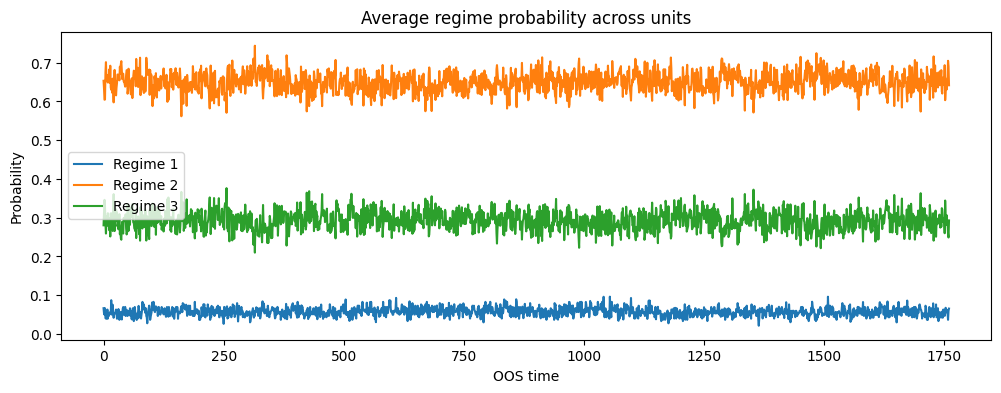

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.plot(mean_gamma[:,0], label="Regime 1")
plt.plot(mean_gamma[:,1], label="Regime 2")
plt.plot(mean_gamma[:,2], label="Regime 3")

plt.title("Average regime probability across units")
plt.xlabel("OOS time")
plt.ylabel("Probability")
plt.legend()
plt.show()

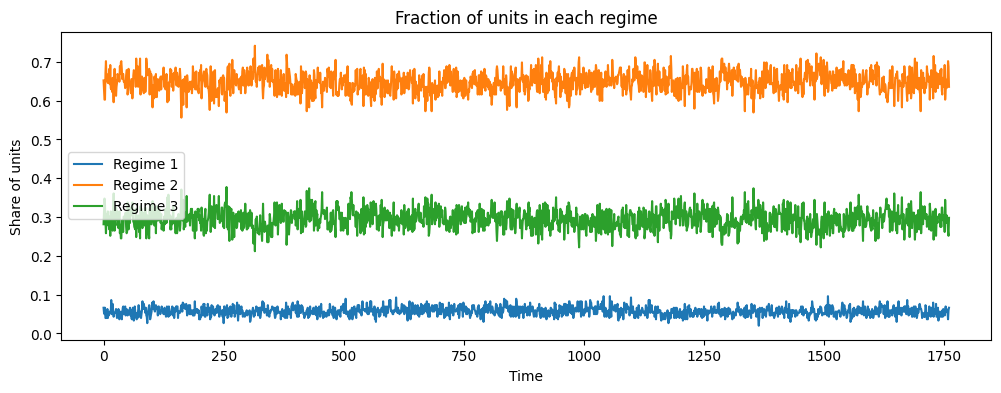

In [10]:
dominant = gamma.argmax(axis=2)

counts = [(dominant == k).mean(axis=0) for k in range(3)]

plt.figure(figsize=(12,4))

for k in range(3):
    plt.plot(counts[k], label=f"Regime {k+1}")

plt.legend()
plt.title("Fraction of units in each regime")
plt.ylabel("Share of units")
plt.xlabel("Time")
plt.show()

In [11]:
Pi = art["Pi"]
np.diag(Pi)

array([0.44971177, 0.78621189, 0.49725466])